## "Uniform" Distribution

In [1]:
from pathlib import Path
import numpy as np
import os


## get path for metisse_wrapper - added by ama
import sys
METISSE_DIR = "/home/poornima/Documents/my_METISSE_project"  
wrapper_dir = os.path.join(METISSE_DIR, "docs", "source", "notebook")
sys.path.insert(0, wrapper_dir)

import metisse_wrapper as mw



In [2]:
import pandas as pd
import glob
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [3]:
### Delete all output .dat files to have a clean output folder

# Define the folder
folder = Path.cwd() / "run" / "output"

# Delete all files inside it
for file in folder.iterdir():
    if file.is_file():
        file.unlink()

In [4]:
run_dir = os.path.join(os.getcwd(),'run')

# Check if run_dir exists; if not, create it
os.makedirs(run_dir, exist_ok=True)

In [5]:
mw.compile_metisse(METISSE_DIR, run_dir, clean=True)

In [6]:
# Paths to the precomputed stellar track libraries

metisse_params = {
    "metallicity_dir": "/home/poornima/Documents/my_METISSE_project/BoOST/",
    "metallicity_dir_he": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Helium/",
    "Z_accuracy_limit" : 2.0,  ### because for He tracks, z=0.02 and for H tracks z=0.008
}


min_m= 10
max_m = 200.0
main_params = {
    "initial_Z": 0.008,
    "max_age": 2.0e4,
    "number_of_tracks": 40,  ## initial value was 100
    "min_mass": min_m,
    "max_mass": max_m,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}

In [7]:
mw.run_metisse(run_dir,main_params, metisse_params)

 program metisse_main started
 Output folder created successfully.
 program metisse_main executed


In [8]:
base_name = os.path.join(run_dir, 'output')
file_name = glob.glob(base_name + "/*.dat")

num_files = len(file_name)
print(f"Number of .dat files: {num_files}")

Number of .dat files: 40


In [9]:
### Create output images folder to save output images

current_path = Path.cwd()

# Create new folder inside it
output_img_dir = current_path / "output_images"
output_img_dir.mkdir(exist_ok=True)



# Hertzsprung–Russell Diagram

The HR diagram shows a star’s luminosity versus effective temperature.
Here, we visualize METISSE’s output using a Hertzsprung–Russell diagram (HRD).
The following script plots Hertzsprung–Russell diagram (HRD) from METISSE output files, color-coded by stellar mass.

In [10]:
base_name = os.path.join(run_dir, 'output')
file_name = glob.glob(base_name + "/*.dat")

num_files = len(file_name)
print(f"Number of .dat files: {num_files}")

Number of .dat files: 40


i 40


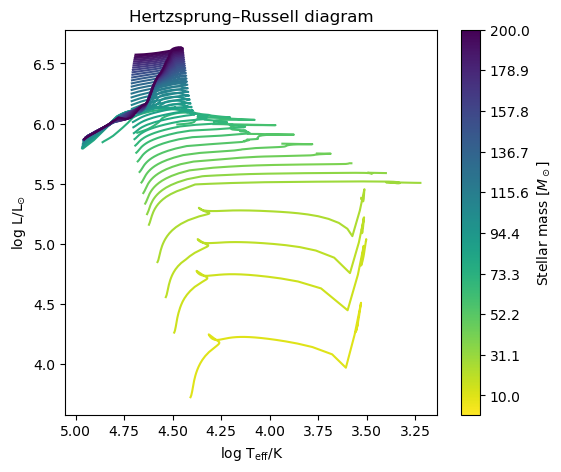

In [11]:
# Linear normalization for colorbar
norm = mpl.colors.Normalize(vmin=0.0, vmax=max_m)
cmap = mpl.cm.ScalarMappable(norm=norm, cmap='viridis_r')
cmap.set_array([])

# --- Read all .dat track files ---
base_name = os.path.join(run_dir, 'output')
file_name = glob.glob(base_name + "/*.dat")
file_name.sort()

fig, ax = plt.subplots(figsize=(6,5))
phase_lim = 5                # Limit the phases for clarity

i=0

mass_array = []
lowest_eff_tem_array = []

# --- Plot each track ---
for eachfile in file_name:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

    i = i+1

    # Plot track with color determined by mass
    ax.plot(Teff, L, color=cmap.to_rgba(m))

    low_eff_tem = min(evolve_data['log_Teff'])

    mass_array.append(m)
    lowest_eff_tem_array.append(low_eff_tem)

print('i',i)

# --- Add colorbar for stellar mass ---
cbar = plt.colorbar(cmap, ax=ax)
cbar.set_label(r'Stellar mass [$M_\odot$]')
ticks = np.linspace(min_m, max_m, 10)  
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.1f}" for t in ticks]) 
cbar.update_ticks()

ax.set_xlabel(r'log T$_{\mathrm{eff}}$/K')
ax.set_ylabel(r'log L/L$_{\odot}$')
ax.invert_xaxis()
ax.set_title("Hertzsprung–Russell diagram")

img_title = "HR_diag"

save_name = output_img_dir/f"Uniform_{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")

In [12]:
import pandas as pd

table = pd.DataFrame({
    'T_eff(K)': 10**np.array(lowest_eff_tem_array),
    'Mass(Solar Mass)': mass_array
})

print(table)

        T_eff(K)  Mass(Solar Mass)
0    3375.833356             10.00
1    3175.031220             14.87
2    3256.716841             19.74
3    3243.747198             24.61
4    1668.253328             29.48
5    2513.008746             34.35
6    3785.733167             39.23
7    4837.901257             44.10
8    6020.187255             48.97
9    7491.279484             53.84
10   9321.718847             58.71
11  11941.833178             63.58
12  15988.473447             68.46
13  20765.720297             73.33
14  24236.114746             78.20
15  24881.124250             83.07
16  25275.514226             87.94
17  25602.890571             92.82
18  25871.642415             97.69
19  26090.836304            102.56
20  26270.540003            107.43
21  26421.106400            112.30
22  26553.330438            117.17
23  26677.737812            122.05
24  26797.914676            126.92
25  26913.860683            131.79
26  27025.516329            136.66
27  27132.761666    